**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_copy = df_original.copy()
df_copy.drop(columns=['sii','PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [3]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [4]:
df = encoder_labels_categoriques(df_copy)

In [5]:
# 1. Identifier les colonnes qui commencent par "PCIAT-PCIAT_"
columns2remove = [c for c in df.columns if c.startswith("PCIAT-PCIAT_")]

# 2. Les supprimer du DataFrame
df = df.drop(columns=columns2remove)

### Data preparation & Split

In [25]:
physical_activity_vars = ['Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-Height',
       'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'PAQ_A-Season', 'PAQ_A-PAQ_A_Total', 'PAQ_C-Season',
       'PAQ_C-PAQ_C_Total', 'PCIAT-Season', 'SDS-Season', 'SDS-SDS_Total_Raw',
       'SDS-SDS_Total_T', 'PreInt_EduHx-Season',
       'PreInt_EduHx-computerinternet_hoursday', 'Physical-BMI_New',
       'FGC_SitReach_Avg', 'FGC_Grip_Avg', 'PAQ_Total', 'Endurance_Total_Sec']

In [28]:
corrs = df[physical_activity_vars + ['BIA-BIA_BMI']].corr()['BIA-BIA_BMI']

# Filtrer selon seuil (valeur absolue entre 0.001 et 0.50)
filtered_corrs = corrs[(corrs.abs() >= 0.1) & (corrs.abs() <= 0.5)]

# Trier
filtered_corrs = filtered_corrs.sort_values()

print(filtered_corrs)

PAQ_A-Season                             -0.286248
FGC-FGC_SRL_Zone                         -0.111722
FGC-FGC_SRR_Zone                         -0.108034
Physical-Diastolic_BP                     0.126778
FGC-FGC_CU                                0.222915
PreInt_EduHx-computerinternet_hoursday    0.237655
Physical-Systolic_BP                      0.248734
FGC-FGC_GSND                              0.255014
FGC-FGC_GSD                               0.272048
FGC_Grip_Avg                              0.288111
BIA-BIA_BMC                               0.344402
Basic_Demos-Age                           0.392574
BIA-BIA_Frame_num                         0.412097
Physical-BMI_New                          0.444297
BIA-BIA_DEE                               0.457725
BIA-BIA_LDM                               0.460624
Physical-Height                           0.468727
Physical-Waist_Circumference              0.483220
Name: BIA-BIA_BMI, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [47]:
features = [
    'PAQ_A-Season',
    'FGC-FGC_SRL_Zone',
    'FGC-FGC_SRR_Zone',
    'Physical-Diastolic_BP',
    'FGC-FGC_CU',
    'PreInt_EduHx-computerinternet_hoursday',
    'Physical-Systolic_BP',
    'FGC-FGC_GSND',
    'FGC-FGC_GSD',
    'FGC_Grip_Avg',
    'BIA-BIA_BMC',
    'Basic_Demos-Age',
    'BIA-BIA_Frame_num',
    'BIA-BIA_DEE',
    'BIA-BIA_LDM',
    'Physical-Height',
    'Physical-Waist_Circumference'
]
target = "BIA-BIA_BMI"

X = df[features]
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Total features: {X_train.shape[1]}")

Total features: 17


In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


In [50]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R² score: 0.342
RMSE: 2.856


In [51]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                                   Feature  Coefficient
16            Physical-Waist_Circumference     0.799605
12                       BIA-BIA_Frame_num     0.765032
14                             BIA-BIA_LDM     0.523723
13                             BIA-BIA_DEE     0.472857
10                             BIA-BIA_BMC     0.293815
6                     Physical-Systolic_BP     0.142634
5   PreInt_EduHx-computerinternet_hoursday     0.093579
15                         Physical-Height     0.064507
3                    Physical-Diastolic_BP     0.057511
8                              FGC-FGC_GSD     0.042680
9                             FGC_Grip_Avg     0.039708
7                             FGC-FGC_GSND     0.030209
2                         FGC-FGC_SRR_Zone     0.018768
11                         Basic_Demos-Age    -0.019030
1                         FGC-FGC_SRL_Zone    -0.019970
0                             PAQ_A-Season    -0.147209
4                               FGC-FGC_CU    -0

In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.38150436716395486


In [53]:
# Feature importance

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# sort descending
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df[:10]) # Top 10 features

                         Feature  Importance
14                   BIA-BIA_LDM    0.321028
16  Physical-Waist_Circumference    0.110486
12             BIA-BIA_Frame_num    0.091683
13                   BIA-BIA_DEE    0.073526
10                   BIA-BIA_BMC    0.070321
15               Physical-Height    0.050650
6           Physical-Systolic_BP    0.050587
3          Physical-Diastolic_BP    0.039862
8                    FGC-FGC_GSD    0.037530
4                     FGC-FGC_CU    0.037061


In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

### Models implementation

In [55]:
xgb_pipe = Pipeline([
    ("model", XGBRegressor(random_state=42))
])

param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [50, 100, 150],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [56]:
rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

### Trainning

In [58]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 150}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 150}


### Results 

In [59]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE RMSE     R2
Random Forest (Ottimizzato) 1.50 2.70 0.4102
      XGBoost (Ottimizzato) 1.56 2.75 0.3895


### Visualizzation

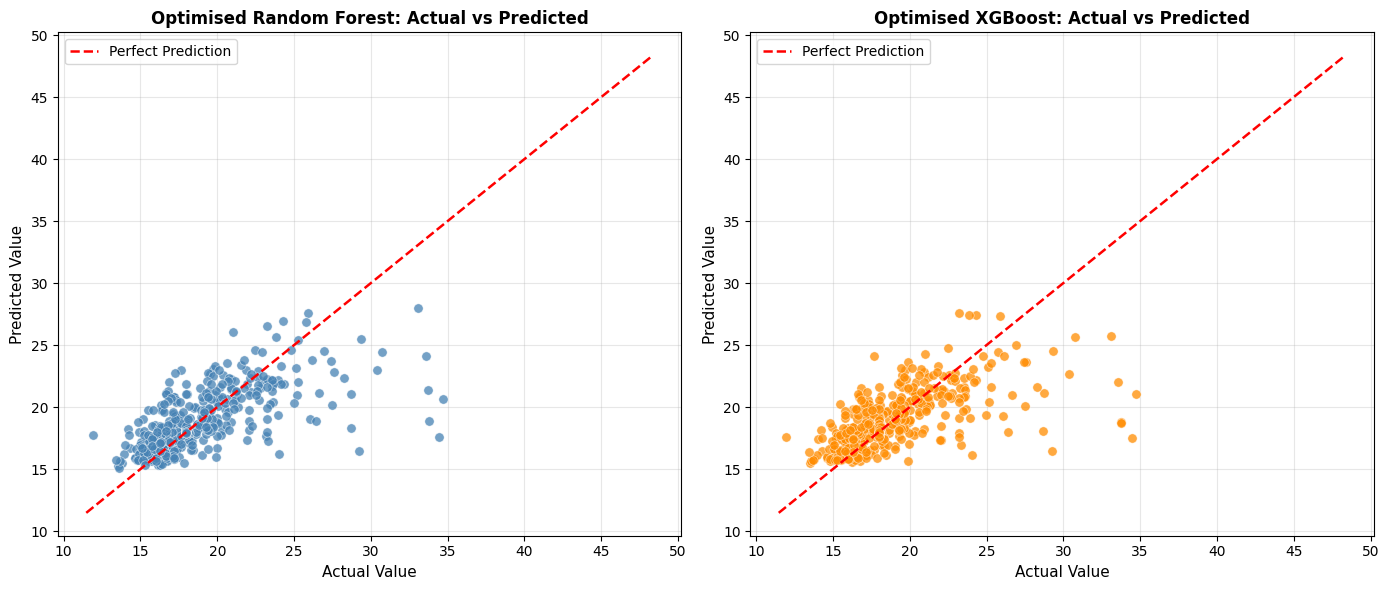

In [62]:
import matplotlib.pyplot as plt
import numpy as np

n_sample = 500
idx = np.random.choice(len(y_test), size=min(n_sample, len(y_test)), replace=False)

y_sample        = y_test.iloc[idx] if hasattr(y_test, "iloc") else y_test[idx]
pred_rf_sample  = predizioni["Random Forest (Ottimizzato)"][idx]
pred_xgb_sample = predizioni["XGBoost (Ottimizzato)"][idx]

plt.figure(figsize=(14, 6))

for i, (pred, color, title) in enumerate([
    (pred_rf_sample,  "steelblue",  "Optimised Random Forest: Actual vs Predicted"),
    (pred_xgb_sample, "darkorange", "Optimised XGBoost: Actual vs Predicted"),
], start=1):
    plt.subplot(1, 2, i)
    plt.scatter(
        y_sample, pred,
        alpha=0.75,       # bien visible sans surcharge
        s=45,             # taille suffisante
        color=color,
        edgecolors="white",  # contour blanc pour séparer les points
        linewidths=0.4,
        zorder=3
    )
    lims = [y_test.min(), y_test.max()]
    plt.plot(lims, lims, "r--", lw=1.8, label="Perfect Prediction", zorder=4)
    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Actual Value", fontsize=11)
    plt.ylabel("Predicted Value", fontsize=11)
    plt.grid(True, alpha=0.3)   # grille discrète pour ne pas noyer les points
    plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

### New set of variable to predict Basic_Demos_Age

In [63]:
# Variables explicatives améliorées

features = [
    "Fitness_Endurance-Time_Sec",
    "FGC-FGC_GSD",
    "BIA-BIA_BMR",
    "BIA-BIA_FFM",
    "BIA-BIA_LST",
    "BIA-BIA_TBW",
    "PAQ_A-PAQ_A_Total",
    "Physical-Weight",
    "Physical-Height",
    "PreInt_EduHx-computerinternet_hoursday"
]

target = "Basic_Demos-Age"

# Drop NaN
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Total features: {X_train.shape[1]}")

Total features: 10


### Models implementation

In [64]:
xgb_pipe = Pipeline([
    ("model", XGBRegressor(random_state=42))
])

param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [50, 100, 150],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [65]:
rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

### Trainning

In [66]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 150}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 150}


### Results 

In [67]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE RMSE     R2
Random Forest (Ottimizzato) 1.47 2.14 0.6450
      XGBoost (Ottimizzato) 1.53 2.21 0.6213


### Visualizzation

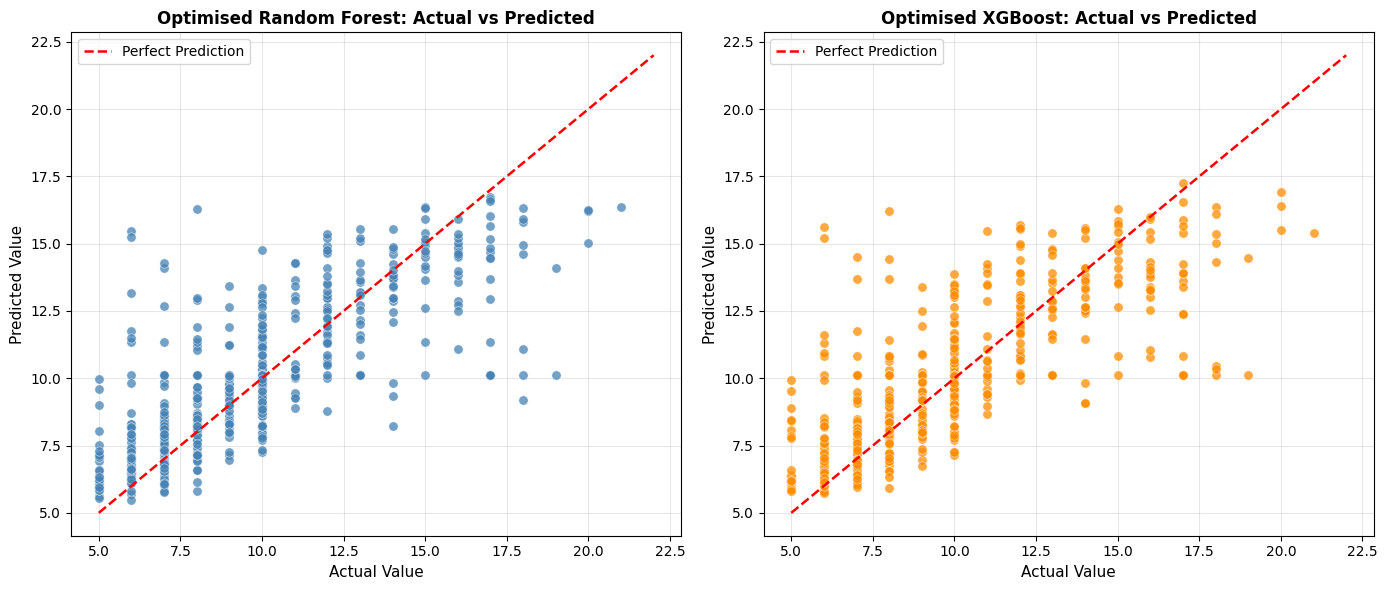

In [68]:
import matplotlib.pyplot as plt
import numpy as np

n_sample = 500
idx = np.random.choice(len(y_test), size=min(n_sample, len(y_test)), replace=False)

y_sample        = y_test.iloc[idx] if hasattr(y_test, "iloc") else y_test[idx]
pred_rf_sample  = predizioni["Random Forest (Ottimizzato)"][idx]
pred_xgb_sample = predizioni["XGBoost (Ottimizzato)"][idx]

plt.figure(figsize=(14, 6))

for i, (pred, color, title) in enumerate([
    (pred_rf_sample,  "steelblue",  "Optimised Random Forest: Actual vs Predicted"),
    (pred_xgb_sample, "darkorange", "Optimised XGBoost: Actual vs Predicted"),
], start=1):
    plt.subplot(1, 2, i)
    plt.scatter(
        y_sample, pred,
        alpha=0.75,       # bien visible sans surcharge
        s=45,             # taille suffisante
        color=color,
        edgecolors="white",  # contour blanc pour séparer les points
        linewidths=0.4,
        zorder=3
    )
    lims = [y_test.min(), y_test.max()]
    plt.plot(lims, lims, "r--", lw=1.8, label="Perfect Prediction", zorder=4)
    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Actual Value", fontsize=11)
    plt.ylabel("Predicted Value", fontsize=11)
    plt.grid(True, alpha=0.3)   # grille discrète pour ne pas noyer les points
    plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

##### Distribuzione dei Residui (Analisi dell'Errore)

Un grafico fondamentale per valutare un modello di regressione è lo studio dei residui (ovvero la differenza tra il valore reale e quello predetto: $y_{\text{vero}} - y_{\text{predetto}}$).
Se il modello è robusto, i residui devono distribuirsi come una campana gaussiana centrata sullo zero. Se ci sono asimmetrie, capiamo dove il modello sta sbagliando sistematicamente.

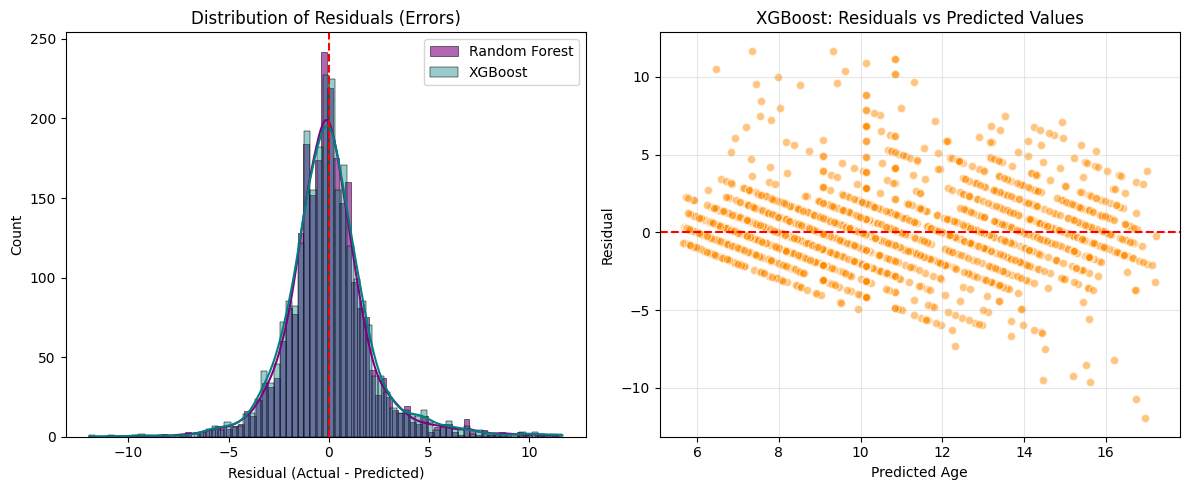

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcolo dei residui per entrambi i modelli
residui_rf = y_test - predizioni["Random Forest (Ottimizzato)"]
residui_xgb = y_test - predizioni["XGBoost (Ottimizzato)"]

plt.figure(figsize=(12, 5))

# Istogramma dei residui
plt.subplot(1, 2, 1)
sns.histplot(residui_rf, kde=True, color="purple", alpha=0.6, label="Random Forest")
sns.histplot(residui_xgb, kde=True, color="teal", alpha=0.4, label="XGBoost")
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()

# Scatter plot dei residui vs Valori Predetti (per vedere l'eteroschedasticità)
plt.subplot(1, 2, 2)
plt.scatter(
    predizioni["XGBoost (Ottimizzato)"],
    residui_xgb,
    alpha=0.5,
    color="darkorange",
    edgecolors="w",
)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("XGBoost: Residuals vs Predicted Values")
plt.xlabel("Predicted Age")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()